In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

colors = ["#280536", "#d10d6f"]

In [3]:
from tensorflow.keras.datasets import mnist

In [4]:
# Splitting into train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display dataset shapes
print("Training:", x_train.shape, y_train.shape)
print("Testing:", x_test.shape, y_test.shape)

Training: (60000, 28, 28) (60000,)
Testing: (10000, 28, 28) (10000,)


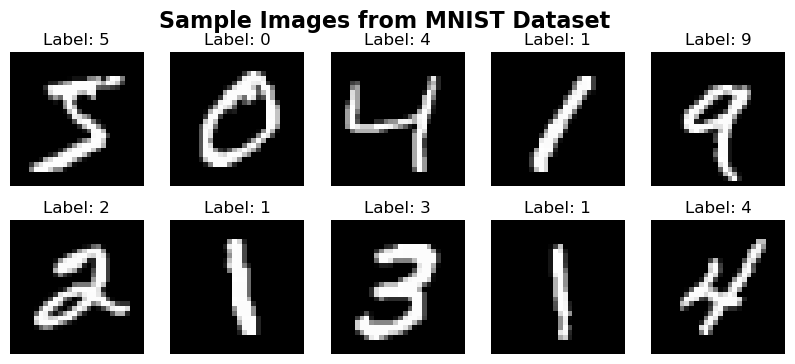

In [5]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Images from MNIST Dataset", fontsize=16, fontweight='bold')
plt.show()

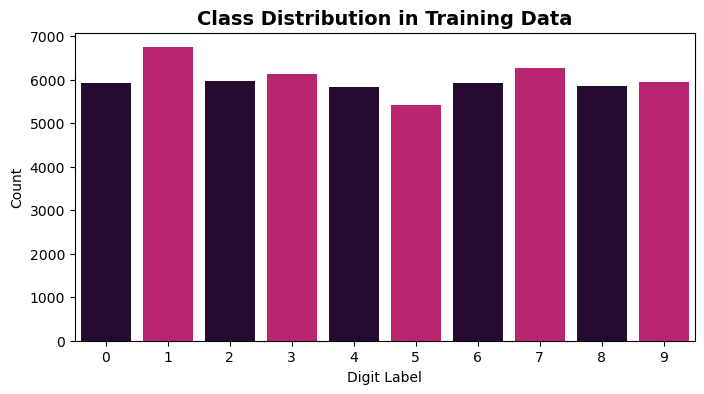

In [6]:
plt.figure(figsize=(8,4))
sns.countplot(x=y_train, palette=colors)
plt.title("Class Distribution in Training Data", fontsize=14, fontweight='bold')
plt.xlabel("Digit Label")
plt.ylabel("Count")
plt.show()

In [7]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print("After normalization:")
print("Training data min:", x_train.min(), "max:", x_train.max())
print("Testing data min:", x_test.min(), "max:", x_test.max())

After normalization:
Training data min: 0.0 max: 1.0
Testing data min: 0.0 max: 1.0


In [8]:
x_train = x_train.reshape((x_train.shape[0], 28*28))
x_test = x_test.reshape((x_test.shape[0], 28*28))

In [9]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [10]:
model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss = 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
                )

In [11]:
early_stopping = EarlyStopping(
    monitor='val_loss',      
    patience=2,             
    min_delta=0.001,         
    restore_best_weights=True 
)

In [12]:
model.fit(
        x = x_train,
        y = y_train,
        batch_size = 16,
        epochs = 10,
#        verbose = 0,
        shuffle=False,
        validation_split = 0.1,
        callbacks=[early_stopping]
        )

Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9304 - loss: 0.2325 - val_accuracy: 0.9662 - val_loss: 0.1136
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9689 - loss: 0.1024 - val_accuracy: 0.9723 - val_loss: 0.0921
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9789 - loss: 0.0693 - val_accuracy: 0.9742 - val_loss: 0.0880
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9846 - loss: 0.0509 - val_accuracy: 0.9732 - val_loss: 0.0992
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9871 - loss: 0.0404 - val_accuracy: 0.9760 - val_loss: 0.0945


In [13]:
train_loss, train_acc = model.evaluate(x_train, y_train)
test_loss, test_acc = model.evaluate(x_test, y_test)
print('\nдля нейронной сети accuracy метрика для обучающей \ тестовой выборки:', train_acc, ' \ ', test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0563
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.0908  

для нейронной сети accuracy метрика для обучающей \ тестовой выборки: 0.9820500016212463  \  0.9703999757766724


In [14]:
# piplain

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

In [15]:
class My_Dataset():
    def __init__(self, x, y):
        self.x_train, self.x_test, self.y_train, self.y_test

In [16]:
class NeuralNetworkTrainer():
    def __init__(self, epochs=10, batch_size=16,  learning_rate=1e-3):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.model = None

    def fit(self, X, y=None):
        #input_dim = X.shape[1]
        model = keras.Sequential([
            keras.layers.Dense(128, activation='relu', input_shape=(784,)),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(10, activation='softmax')
        ])

        model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy']
                        )

        early_stopping = EarlyStopping(
                monitor='val_loss',      
                patience=2,             
                min_delta=0.001,         
                restore_best_weights=True 
            )

        model.fit(
            x = x_train,
            y = y_train,
            batch_size = 16,
            epochs = 10,
    #        verbose = 0,
            shuffle=False,
            validation_split = 0.1,
            callbacks=[early_stopping]
        )

        self.model = model
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)        

In [17]:
pipe = Pipeline([
        ('neural_network_trainer', NeuralNetworkTrainer(epochs=20, batch_size=16))
    ])

pipe.fit(x_train, y_train)

Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9306 - loss: 0.2355 - val_accuracy: 0.9653 - val_loss: 0.1168
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9684 - loss: 0.1040 - val_accuracy: 0.9708 - val_loss: 0.1042
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9782 - loss: 0.0708 - val_accuracy: 0.9713 - val_loss: 0.0897
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9841 - loss: 0.0514 - val_accuracy: 0.9767 - val_loss: 0.0899
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9874 - loss: 0.0406 - val_accuracy: 0.9755 - val_loss: 0.0908


Pipeline(steps=[('neural_network_trainer',
                 <__main__.NeuralNetworkTrainer object at 0x000001E99225BCB0>)])

In [31]:
keras_model = pipe.named_steps['neural_network_trainer'].model

keras_model.save('my_neural_network.h5')   

In [18]:
from tensorflow.keras.datasets import fashion_mnist

In [36]:
# Splitting into train and test sets
(x_train2, y_train2), (x_test2, y_test2) = fashion_mnist.load_data()

# Display dataset shapes
print("Training:", x_train2.shape, y_train2.shape)
print("Testing:", x_test2.shape, y_test2.shape)

Training: (60000, 28, 28) (60000,)
Testing: (10000, 28, 28) (10000,)


In [37]:
x_train2 = x_train2.astype('float32') / 255
x_test2 = x_test2.astype('float32') / 255

In [38]:
x_train2 = x_train2.reshape(-1, 784)    
x_test2  = x_test2.reshape(-1, 784)

In [39]:
train_mask = y_train2 != 0
test_mask  = y_test2 != 0

In [40]:
x_train_filtered = x_train2[train_mask]
y_train_filtered = y_train2[train_mask] - 1   # сдвиг: теперь классы 0..8

x_test_filtered = x_test2[test_mask]
y_test_filtered = y_test2[test_mask] - 1

print("Оставшиеся классы:", np.unique(y_train_filtered))
print("Размер выборок:", x_train_filtered.shape, x_test_filtered.shape)

Оставшиеся классы: [0 1 2 3 4 5 6 7 8]
Размер выборок: (54000, 784) (9000, 784)


In [41]:
for layer in model.layers[:-1]:
    layer.trainable = False  

In [42]:
model = keras.models.load_model('my_neural_network.h5')   


In [43]:
model.pop()  # удаляем старый выходной слой (10 классов)
model.add(keras.layers.Dense(9, activation='softmax', name='new_output'))

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучаем на ваших данных (9 классов)
model.fit(x_train_filtered, y_train_filtered,
          batch_size=16, epochs=20,
          validation_split=0.1)

Epoch 1/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8444 - loss: 0.4411 - val_accuracy: 0.8809 - val_loss: 0.3394
Epoch 2/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8892 - loss: 0.3100 - val_accuracy: 0.8806 - val_loss: 0.3397
Epoch 3/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9001 - loss: 0.2777 - val_accuracy: 0.8881 - val_loss: 0.3038
Epoch 4/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9068 - loss: 0.2550 - val_accuracy: 0.9007 - val_loss: 0.2896
Epoch 5/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9115 - loss: 0.2428 - val_accuracy: 0.8993 - val_loss: 0.2914
Epoch 6/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9170 - loss: 0.2275 - val_accuracy: 0.9009 - val_loss: 0.2799
Epoch 7/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9216 - loss: 0.2147 - val_accuracy: 0.9030 - val_loss: 0.2867
Epoch 8/20
3038/3038 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9236 - loss: 0